# 06 · Input completeness

How much detail does a typical ORD reaction actually carry about its inputs? This notebook looks at two proxies for completeness: the number of `ReactionInput`s recorded per reaction, and the number of `Compound` components recorded per input -- compared between hand-curated submissions and the bulk USPTO-mined datasets.

In [1]:
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from ord_analysis.db import get_engine
from ord_analysis import queries

load_dotenv()
engine = get_engine()
sns.set_theme(style="whitegrid")

## Inputs per reaction

`queries.inputs_per_reaction` counts `ReactionInput`s in SQL (rather than pulling raw rows into pandas), since `Reaction` has millions of rows.

In [2]:
inputs = queries.inputs_per_reaction(engine)
print(inputs.shape)
inputs["n_inputs"].describe()

(2428291, 4)


count    2.428291e+06
mean     2.445149e+00
std      1.707310e+00
min      1.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      3.000000e+00
max      8.100000e+01
Name: n_inputs, dtype: float64

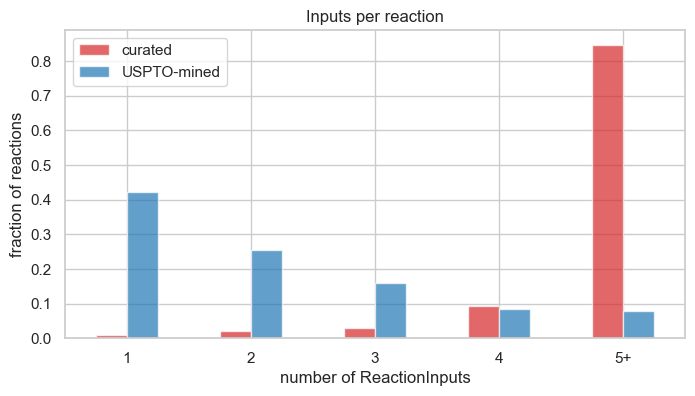

In [3]:
def bucket_count(n, cap=5):
    return str(n) if n < cap else f"{cap}+"

inputs["n_inputs_bucket"] = inputs["n_inputs"].map(bucket_count)
bucket_order = [str(i) for i in range(1, 5)] + ["5+"]

by_group = (
    inputs.groupby("is_uspto")["n_inputs_bucket"]
    .value_counts(normalize=True)
    .rename("fraction")
    .reset_index()
    .pivot(index="n_inputs_bucket", columns="is_uspto", values="fraction")
    .reindex(bucket_order)
)

fig, ax = plt.subplots(figsize=(8, 4))
by_group.plot.bar(ax=ax, color={False: "tab:red", True: "tab:blue"}, alpha=0.7)
ax.set_title("Inputs per reaction")
ax.set_xlabel("number of ReactionInputs")
ax.set_ylabel("fraction of reactions")
ax.legend(["curated", "USPTO-mined"])
plt.xticks(rotation=0)
plt.show()

## Components per input

A `ReactionInput` can contain multiple `Compound` components (e.g. a mixed solvent, or a catalyst + ligand recorded as one input). `queries.components_per_input` counts these the same way, in SQL.

In [4]:
components = queries.components_per_input(engine)
print(components.shape)
components["n_components"].describe()

(5937531, 4)


count    5.937531e+06
mean     2.012627e+00
std      1.475217e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      2.900000e+01
Name: n_components, dtype: float64

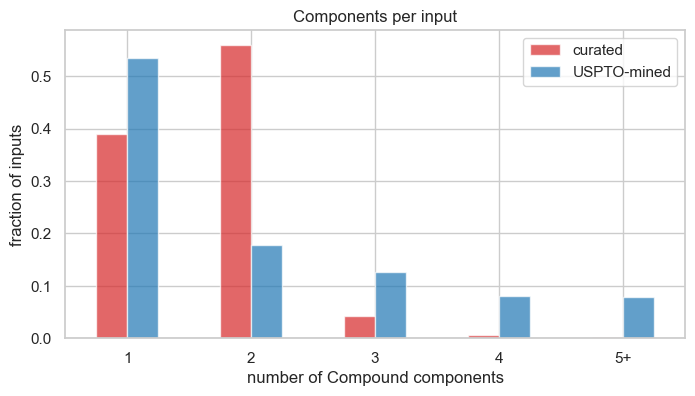

In [5]:
components["n_components_bucket"] = components["n_components"].map(bucket_count)

by_group = (
    components.groupby("is_uspto")["n_components_bucket"]
    .value_counts(normalize=True)
    .rename("fraction")
    .reset_index()
    .pivot(index="n_components_bucket", columns="is_uspto", values="fraction")
    .reindex(bucket_order)
)

fig, ax = plt.subplots(figsize=(8, 4))
by_group.plot.bar(ax=ax, color={False: "tab:red", True: "tab:blue"}, alpha=0.7)
ax.set_title("Components per input")
ax.set_xlabel("number of Compound components")
ax.set_ylabel("fraction of inputs")
ax.legend(["curated", "USPTO-mined"])
plt.xticks(rotation=0)
plt.show()

## Curated vs. USPTO-mined comparison

A single-input reaction, or an input with only one component, isn't necessarily wrong -- but a dataset where *most* reactions/inputs look like that has much less structured detail to work with than one where multi-component inputs are common.

In [6]:
summary = pd.DataFrame(
    {
        "% reactions with a single input": inputs.groupby("is_uspto")["n_inputs"].apply(lambda s: (s == 1).mean() * 100),
        "% inputs with a single component": components.groupby("is_uspto")["n_components"].apply(lambda s: (s == 1).mean() * 100),
    }
)
summary.index = summary.index.map({False: "curated", True: "USPTO-mined"})
summary.round(1)

,% reactions with a single input,% inputs with a single component
is_uspto,,
curated,0.8,38.9
USPTO-mined,42.3,53.5
